# mplstudio demo

Interactive GUI for styling matplotlib figures in Jupyter.

**Install:**
```bash
pip install mplstudio
```

No special backend needed — just standard `matplotlib`.

## 1. Line plot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mplstudio

x = np.linspace(0, 2 * np.pi, 200)

fig, ax = plt.subplots()
ax.plot(x, np.sin(x), label='sin(x)0')
ax.plot(x, np.cos(x), label='cos(x)0')
ax.plot(x, np.sin(2 * x), label='sin(2x)0')
ax.plot(x, np.sin(x-1), label='sin(x)1')
ax.plot(x, np.cos(x-1), label='cos(x)1')
ax.plot(x, np.sin(2 * x-1), label='sin(2x)1')
ax.plot(x, np.sin(x-2), label='sin(x)2')
ax.plot(x, np.cos(x-2), label='cos(x)2')
ax.plot(x, np.sin(2 * x-2), label='sin(2x)2')
ax.plot(x, np.sin(x-3), label='sin(x)3')
ax.plot(x, np.cos(x-3), label='cos(x)3')
ax.plot(x, np.sin(2 * x-3), label='sin(2x)3')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Trigonometric functions')
ax.legend()
plt.close()  # suppress inline auto-display; studio() will render it

mplstudio.studio(fig)

## 2. Scatter plot

Color pickers and palette changes work on scatter series too.

In [3]:
np.random.seed(0)

fig2, ax2 = plt.subplots()
ax2.scatter(np.random.randn(60), np.random.randn(60), label='group A', alpha=0.7)
ax2.scatter(np.random.randn(60), np.random.randn(60), label='group B', alpha=0.7)
ax2.scatter(np.random.randn(60), np.random.randn(60), label='group C', alpha=0.7)
ax2.set_title('Scatter groups')
ax2.legend()
plt.close()

mplstudio.studio(fig2, show=['legend', 'colors', 'unknown'])

## 3. Programmatic API

All style functions in `mplstudio.style` work without the GUI.

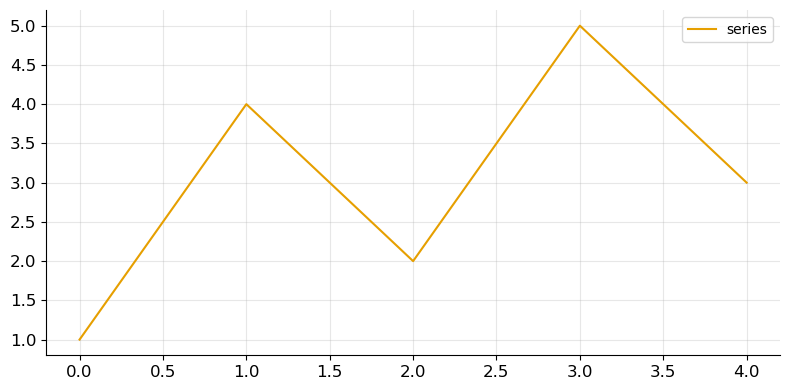

In [2]:
from mplstudio import style as S

fig3, ax3 = plt.subplots()
ax3.plot([1, 4, 2, 5, 3], label='series')
ax3.legend()

S.set_figure_size(fig3, 8, 4)
S.set_font_size(fig3, 14)
S.set_line_colors(fig3, 'Okabe-Ito')
S.set_spine_style(fig3, 'left-bottom')
S.set_grid(fig3, True)
S.set_legend_position(fig3, 'upper right')

plt.tight_layout()
plt.show()

## 4. Color palette preview

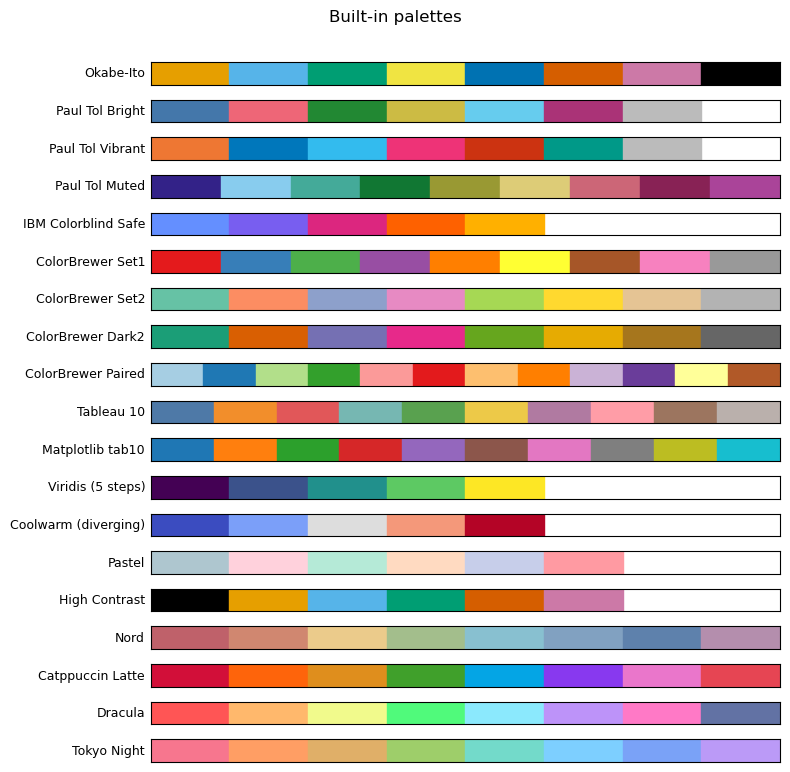

In [6]:
import matplotlib.patches as mpatches

palettes = mplstudio.PALETTES
fig4, axes = plt.subplots(len(palettes), 1, figsize=(8, len(palettes) * 0.4))

for ax, p in zip(axes, palettes):
    for i, color in enumerate(p['colors']):
        ax.add_patch(mpatches.Rectangle((i, 0), 1, 1, color=color))
    ax.set_xlim(0, max(len(p['colors']), 8))
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylabel(p['name'], rotation=0, ha='right', va='center', fontsize=9)

fig4.suptitle('Built-in palettes', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 5. Heatmap (continuous colormap)

mplstudio auto-detects continuous data (`imshow`, `pcolormesh`) and shows a **colormap picker** with a gradient preview instead of the categorical palette controls.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import mplstudio

# 2-D heatmap via imshow
rng = np.random.default_rng(42)
data = rng.standard_normal((12, 12))

fig5, ax5 = plt.subplots()
im = ax5.imshow(data, cmap='viridis')
fig5.colorbar(im, ax=ax5, label='value')
ax5.set_title('Random heatmap')
plt.close()

# Colors section shows "Detected: continuous" → colormap picker with gradient preview
mplstudio.studio(fig5)

## 6. pcolormesh (continuous + diverging)

`pcolormesh` is common for 2-D field data (e.g. atmospheric, oceanographic). mplstudio detects the scalar-mapped mesh and exposes the same colormap controls.

In [8]:
x = np.linspace(-np.pi, np.pi, 60)
y = np.linspace(-np.pi, np.pi, 60)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y)   # diverging data centred around 0

fig6, ax6 = plt.subplots()
pc = ax6.pcolormesh(X, Y, Z, cmap='coolwarm', shading='auto')
fig6.colorbar(pc, ax=ax6, label='sin(x)·cos(y)')
ax6.set_title('sin(x)·cos(y)')
ax6.set_xlabel('x')
ax6.set_ylabel('y')
plt.close()

# Switch to "Diverging" tab in the colormap picker to try RdBu_r, PiYG, seismic…
mplstudio.studio(fig6)

## 7. Mixed figure (categorical + continuous)

When a figure contains both labeled series and a colormap-based artist, mplstudio shows **both** sets of controls.

In [9]:
fig7, ax7 = plt.subplots()

# Continuous background (contourf)
x_c = np.linspace(-3, 3, 80)
y_c = np.linspace(-3, 3, 80)
Xc, Yc = np.meshgrid(x_c, y_c)
Zc = np.exp(-(Xc**2 + Yc**2) / 4)
cf = ax7.contourf(Xc, Yc, Zc, levels=12, cmap='Blues')
fig7.colorbar(cf, ax=ax7, label='Gaussian')

# Categorical overlay (scatter series)
rng2 = np.random.default_rng(0)
for label, color in [('group A', '#E69F00'), ('group B', '#D55E00')]:
    ax7.scatter(rng2.uniform(-2, 2, 30), rng2.uniform(-2, 2, 30),
                label=label, edgecolors='white', linewidths=0.5, s=50)
ax7.legend()
ax7.set_title('Gaussian field + scatter overlay')
plt.close()

# Colors section shows "Detected: mixed" — both palette picker and colormap picker are visible
mplstudio.studio(fig7)